# 🫀 Heart Disease Risk Prediction
## Phase 2: Data Visualization & Preprocessing
---

## 0. Setup & Imports

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='husl')
COLORS = {'no_disease': '#2ecc71', 'disease': '#e74c3c', 'neutral': '#3498db'}

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## 1. Load Dataset

In [2]:
# ── Load the combined 4-center UCI Heart Disease dataset ─────────────
# Kaggle path: /kaggle/input/heart-disease-data/heart_disease_uci.csv
# Local path: heart_disease_uci.csv

try:
    df = pd.read_csv('/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv')
except:
    df = pd.read_csv('heart_disease_uci.csv')

# ── Initial inspection ────────────────────────────────────────────────
print(f"Dataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Features: {df.shape[1]}")
print("\n" + "─"*60)
print("FIRST 5 ROWS:")
df.head()

Dataset Shape: (920, 16)
Rows: 920, Features: 16

────────────────────────────────────────────────────────────
FIRST 5 ROWS:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
# ── Column renaming for clarity ───────────────────────────────────────
# The dataset may have various column names depending on the source
# Standardize to a clean naming convention

# Check current columns
print("Current columns:", df.columns.tolist())

# Rename if needed (UCI standard names)
rename_map = {
    'num': 'target',     # target column
}
df.rename(columns=rename_map, inplace=True)

# Binarize target: 0 = no disease, 1 = disease (values > 0 → 1)
df['target'] = (df['target'] > 0).astype(int)

print("\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nDisease prevalence: {df['target'].mean()*100:.1f}%")

Current columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Target distribution:
target
1    509
0    411
Name: count, dtype: int64

Disease prevalence: 55.3%


## 2. Statistical Analysis

Before any visualization, we examine descriptive statistics to understand the data's scale, spread, and potential anomalies.

In [4]:
# ── Descriptive statistics ────────────────────────────────────────────
print("DESCRIPTIVE STATISTICS")
print("="*80)
df.describe(include='all').T.style.background_gradient(cmap='Blues', axis=1)

DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.000000,nan,nan,nan,460.500000,265.725422,1.000000,230.750000,460.500000,690.250000,920.000000
age,920.000000,nan,nan,nan,53.510870,9.424685,28.000000,47.000000,54.000000,60.000000,77.000000
sex,920,2,Male,726,nan,nan,nan,nan,nan,nan,nan
dataset,920,4,Cleveland,304,nan,nan,nan,nan,nan,nan,nan
cp,920,4,asymptomatic,496,nan,nan,nan,nan,nan,nan,nan
trestbps,861.000000,nan,nan,nan,132.132404,19.066070,0.000000,120.000000,130.000000,140.000000,200.000000
chol,890.000000,nan,nan,nan,199.130337,110.780810,0.000000,175.000000,223.000000,268.000000,603.000000
fbs,830,2,False,692,nan,nan,nan,nan,nan,nan,nan
restecg,918,3,normal,551,nan,nan,nan,nan,nan,nan,nan
thalch,865.000000,nan,nan,nan,137.545665,25.926276,60.000000,120.000000,140.000000,157.000000,202.000000


MISSING VALUES ANALYSIS
          Missing Count  Missing %    Dtype
ca                  611      66.41  float64
thal                486      52.83   object
slope               309      33.59   object
fbs                  90       9.78   object
oldpeak              62       6.74  float64
trestbps             59       6.41  float64
exang                55       5.98   object
thalch               55       5.98  float64
chol                 30       3.26  float64
restecg               2       0.22   object


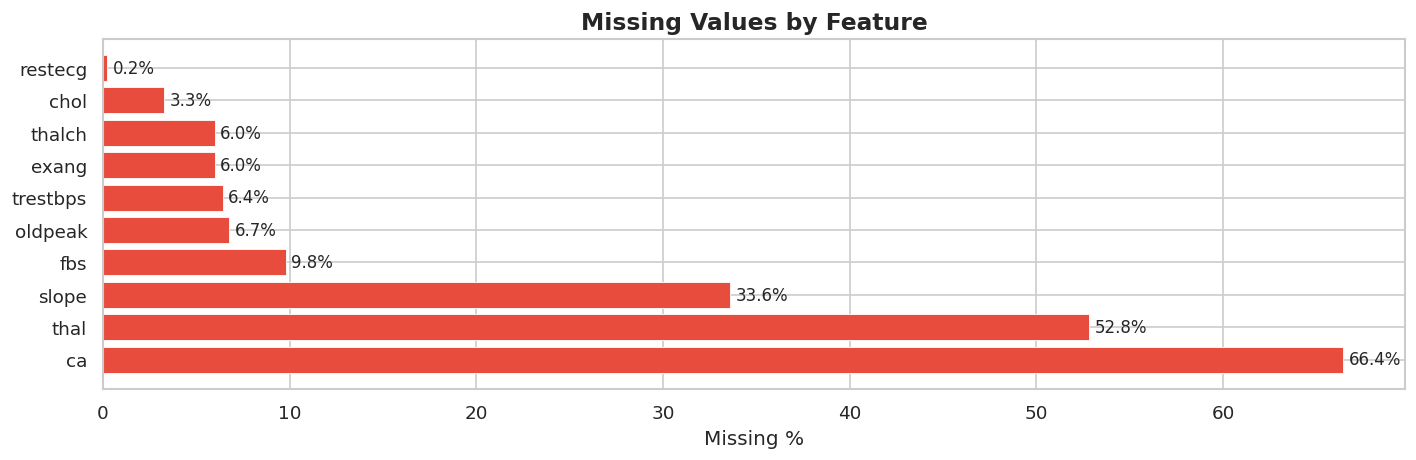


⚠️ Missing values detected — will handle in preprocessing.


In [5]:
# ── Missing value analysis ────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Dtype': df.dtypes
}).sort_values('Missing Count', ascending=False)

print("MISSING VALUES ANALYSIS")
print("="*50)
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 4))
missing_cols = missing_df[missing_df['Missing Count'] > 0]
if len(missing_cols) > 0:
    bars = ax.barh(missing_cols.index, missing_cols['Missing %'], 
                   color='#e74c3c', edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Missing %', fontsize=12)
    ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
    for bar, val in zip(bars, missing_cols['Missing %']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()
    print("\n⚠️ Missing values detected — will handle in preprocessing.")
else:
    print("✅ No missing values found after initial load.")

In [6]:
# ── Data types and cardinality ────────────────────────────────────────
print("DATA TYPES & UNIQUE VALUES")
print("="*50)
type_df = pd.DataFrame({
    'Dtype': df.dtypes,
    'Unique Values': df.nunique(),
    'Sample Values': [df[col].dropna().unique()[:5].tolist() for col in df.columns]
})
print(type_df)

DATA TYPES & UNIQUE VALUES
            Dtype  Unique Values  \
id          int64            920   
age         int64             50   
sex        object              2   
dataset    object              4   
cp         object              4   
trestbps  float64             61   
chol      float64            217   
fbs        object              2   
restecg    object              3   
thalch    float64            119   
exang      object              2   
oldpeak   float64             53   
slope      object              3   
ca        float64              4   
thal       object              3   
target      int64              2   

                                              Sample Values  
id                                          [1, 2, 3, 4, 5]  
age                                    [63, 67, 37, 41, 56]  
sex                                          [Male, Female]  
dataset    [Cleveland, Hungary, Switzerland, VA Long Beach]  
cp        [typical angina, asymptomatic, non-angin

In [7]:
# ── Skewness and Kurtosis ─────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'target']

skew_kurt = pd.DataFrame({
    'Skewness': df[numeric_cols].skew().round(3),
    'Kurtosis': df[numeric_cols].kurt().round(3)
})
skew_kurt['Skew Category'] = skew_kurt['Skewness'].apply(
    lambda x: 'Highly Skewed' if abs(x) > 1 else ('Moderately Skewed' if abs(x) > 0.5 else 'Symmetric')
)

print("SKEWNESS AND KURTOSIS ANALYSIS")
print("="*50)
print(skew_kurt)
print("\n📌 Highly skewed features may need log transformation in preprocessing.")

SKEWNESS AND KURTOSIS ANALYSIS
          Skewness  Kurtosis      Skew Category
id           0.000    -1.200          Symmetric
age         -0.196    -0.383          Symmetric
trestbps     0.213     2.959          Symmetric
chol        -0.614     0.062  Moderately Skewed
thalch      -0.211    -0.480          Symmetric
oldpeak      1.041     1.127      Highly Skewed
ca           1.166     0.199      Highly Skewed

📌 Highly skewed features may need log transformation in preprocessing.


## 3. Visual Analysis

We now generate a comprehensive set of visualizations to deeply understand the data distribution and relationships.

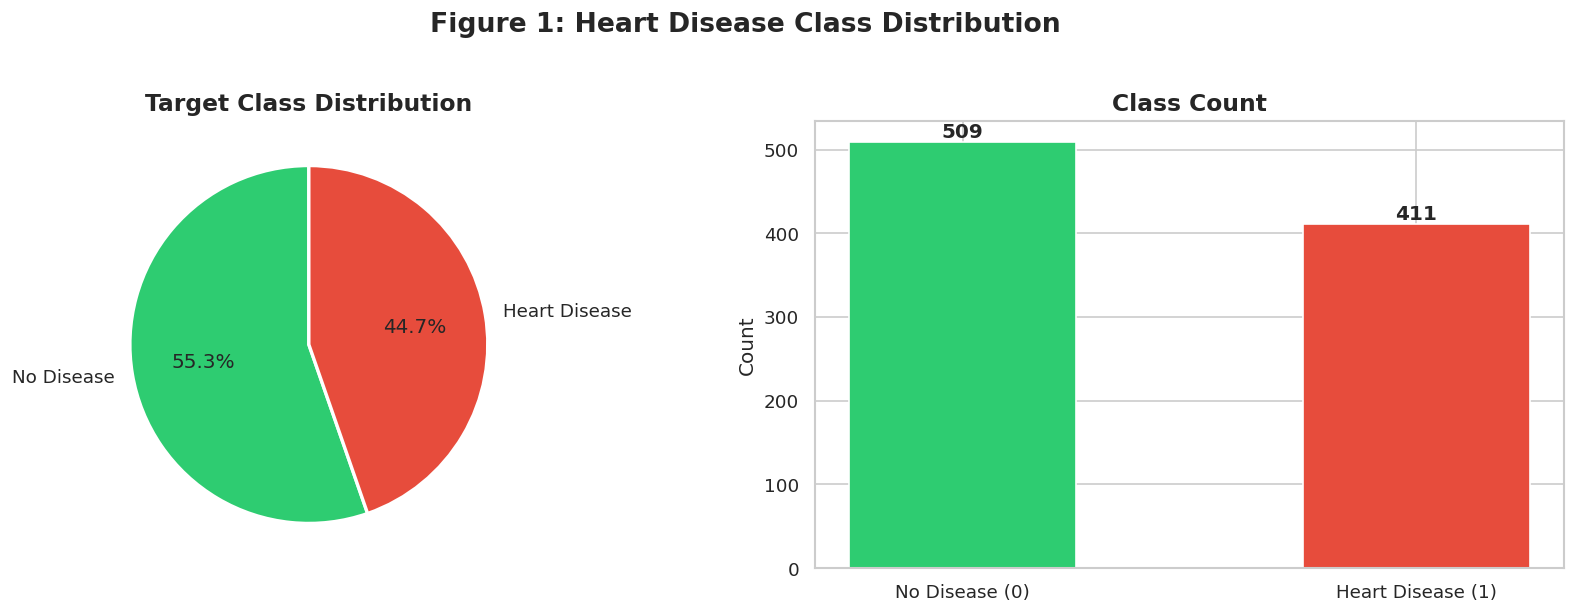


📊 Dataset shows 55.3% positive cases (heart disease).
⚠️ Mild class imbalance present — will apply SMOTE+Tomek Links in preprocessing.


In [8]:
# ── Figure 1: Target Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
counts = df['target'].value_counts()
axes[0].pie(counts, labels=['No Disease', 'Heart Disease'],
            colors=[COLORS['no_disease'], COLORS['disease']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(['No Disease (0)', 'Heart Disease (1)'],
                   counts.values,
                   color=[COLORS['no_disease'], COLORS['disease']],
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Class Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Figure 1: Heart Disease Class Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📊 Dataset shows {counts[1]/sum(counts)*100:.1f}% positive cases (heart disease).")
print("⚠️ Mild class imbalance present — will apply SMOTE+Tomek Links in preprocessing.")

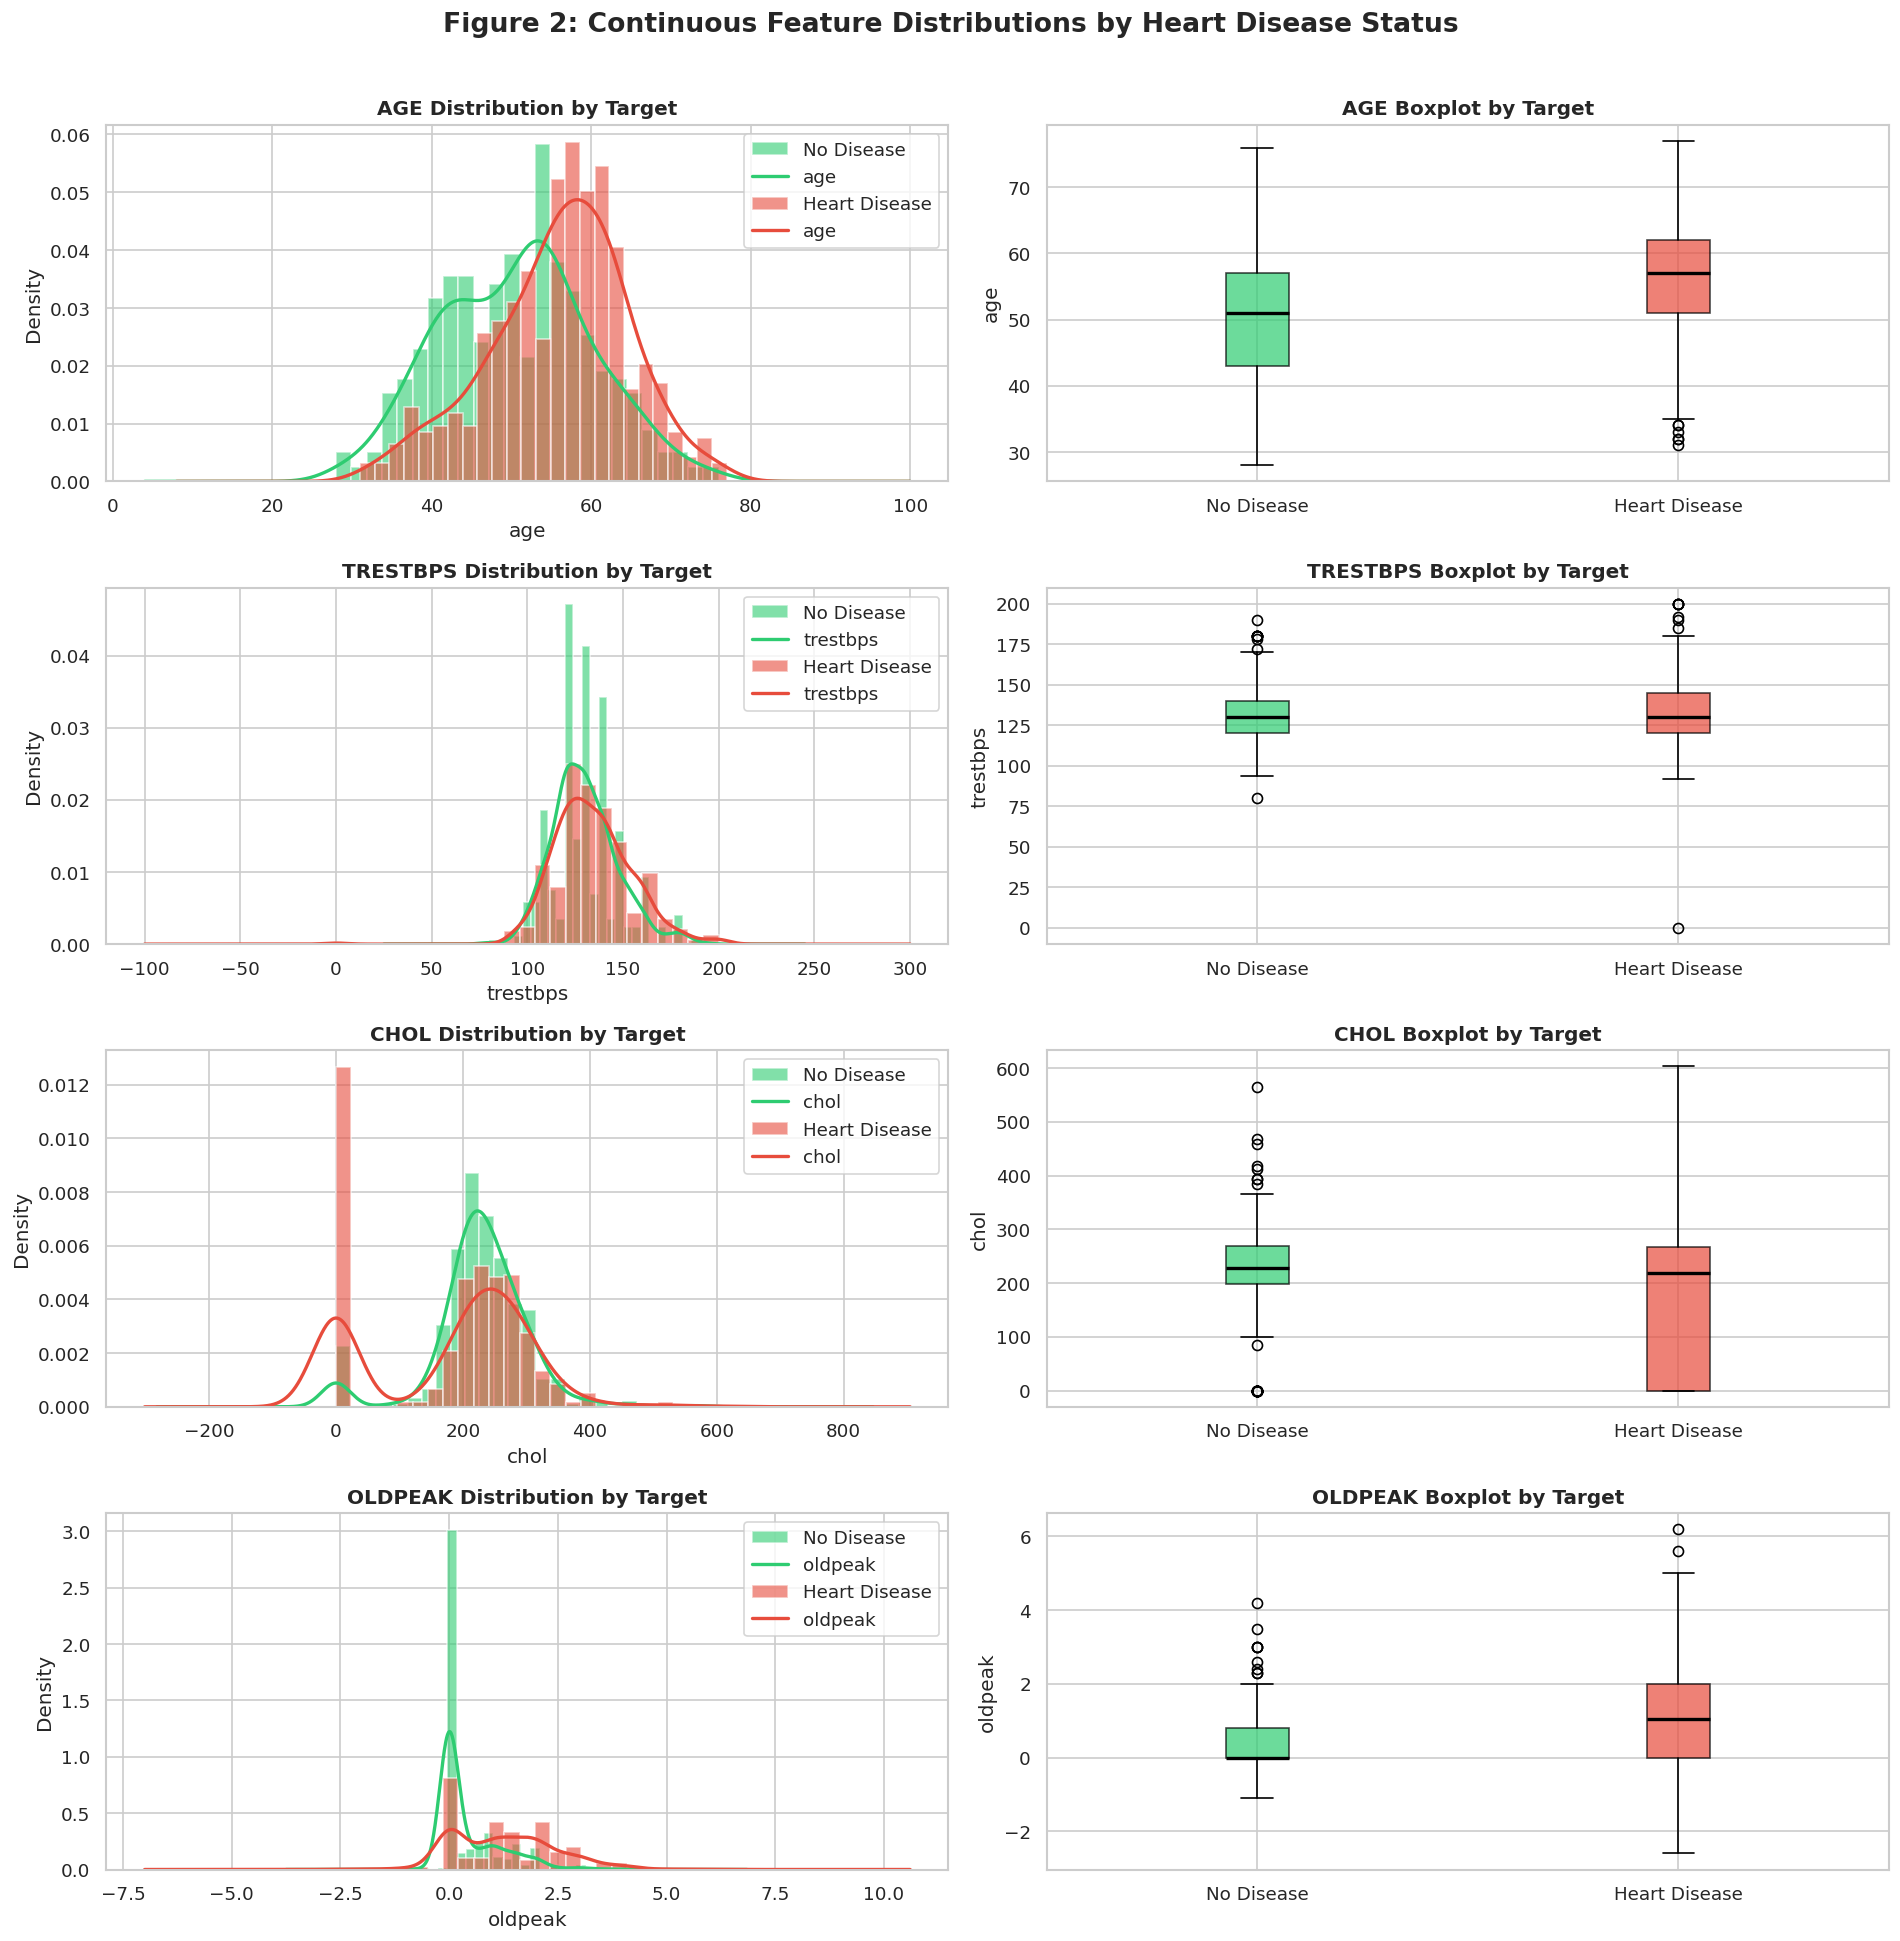


📌 Key Observations:
- AGE: Patients with heart disease tend to be slightly older (peak ~55-60 years)
- TRESTBPS: Higher resting blood pressure seen in heart disease patients
- CHOL: Cholesterol shows wide spread with outliers (values > 400) in both groups
- THALACH: Heart disease patients achieve significantly LOWER max heart rate
- OLDPEAK: Heart disease patients show higher ST depression — strong predictor



In [9]:
# ── Figure 2: Distribution of All Numeric Features ────────────────────
cont_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cont_features = [c for c in cont_features if c in df.columns]

fig, axes = plt.subplots(len(cont_features), 2, figsize=(16, 4*len(cont_features)))

for i, feat in enumerate(cont_features):
    # Histogram with KDE
    for target_val, color, label in [(0, COLORS['no_disease'], 'No Disease'),
                                       (1, COLORS['disease'], 'Heart Disease')]:
        subset = df[df['target'] == target_val][feat].dropna()
        axes[i, 0].hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
        subset.plot.kde(ax=axes[i, 0], color=color, linewidth=2)
    axes[i, 0].set_title(f'{feat.upper()} Distribution by Target', fontweight='bold')
    axes[i, 0].set_xlabel(feat)
    axes[i, 0].set_ylabel('Density')
    axes[i, 0].legend()

    # Box plot
    data_0 = df[df['target'] == 0][feat].dropna()
    data_1 = df[df['target'] == 1][feat].dropna()
    bp = axes[i, 1].boxplot([data_0, data_1],
                             labels=['No Disease', 'Heart Disease'],
                             patch_artist=True,
                             medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor(COLORS['no_disease'])
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(COLORS['disease'])
    bp['boxes'][1].set_alpha(0.7)
    axes[i, 1].set_title(f'{feat.upper()} Boxplot by Target', fontweight='bold')
    axes[i, 1].set_ylabel(feat)

plt.suptitle('Figure 2: Continuous Feature Distributions by Heart Disease Status',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
📌 Key Observations:
- AGE: Patients with heart disease tend to be slightly older (peak ~55-60 years)
- TRESTBPS: Higher resting blood pressure seen in heart disease patients
- CHOL: Cholesterol shows wide spread with outliers (values > 400) in both groups
- THALACH: Heart disease patients achieve significantly LOWER max heart rate
- OLDPEAK: Heart disease patients show higher ST depression — strong predictor
""")

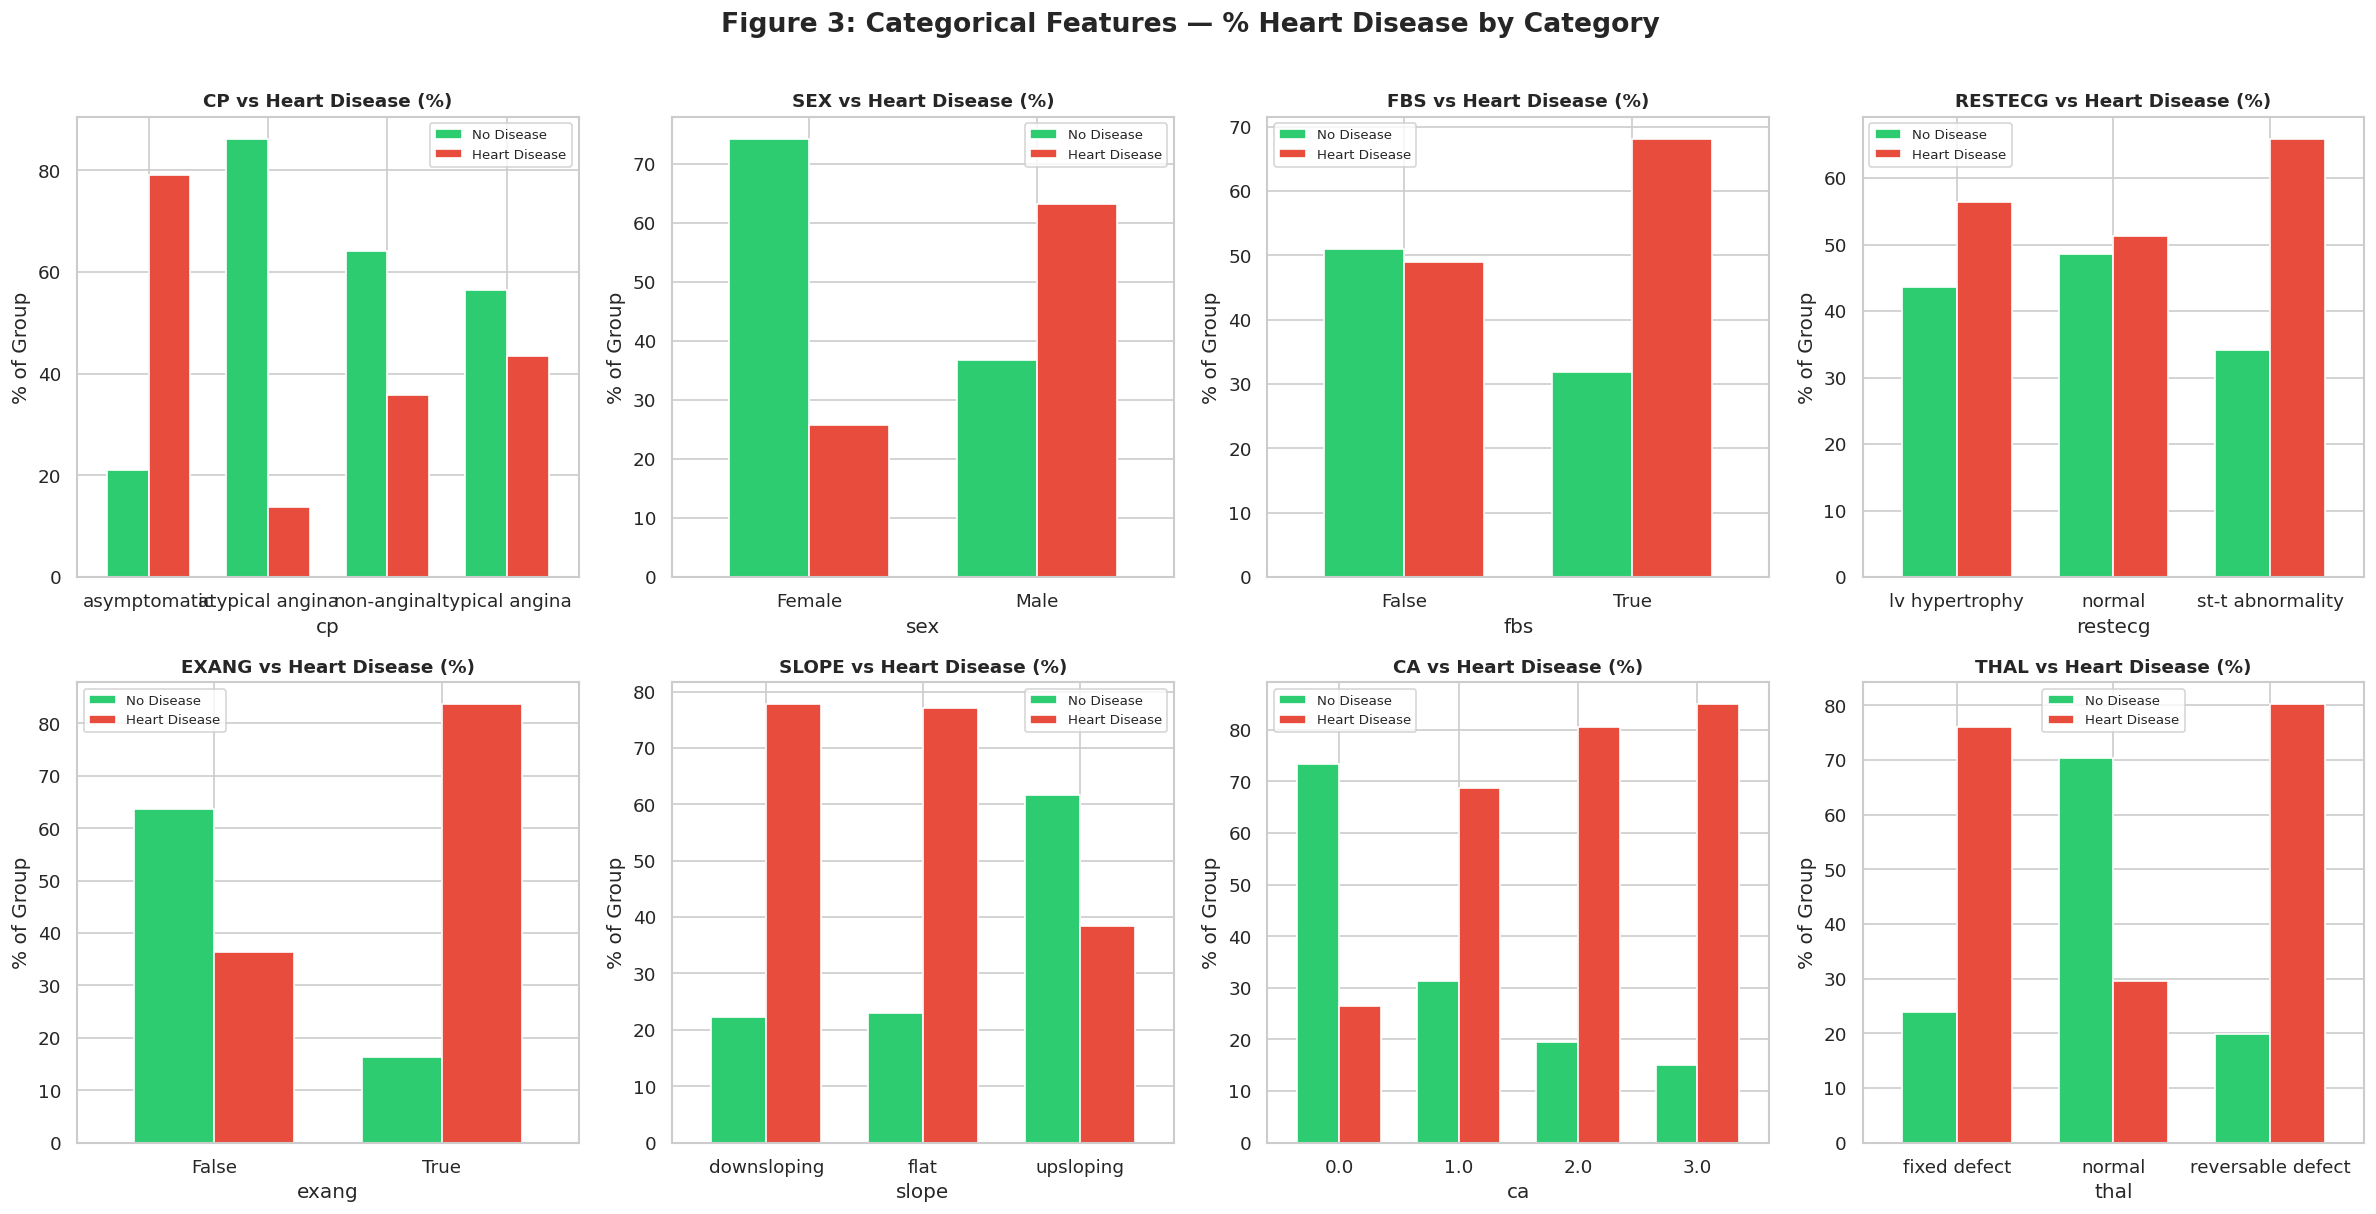


📌 Key Observations:
- CP (Chest Pain): Asymptomatic chest pain (type 0) has highest heart disease rate — counter-intuitive!
- SEX: Males have higher heart disease prevalence in this dataset
- EXANG: Patients with exercise-induced angina have much higher disease rate
- CA: As number of blocked vessels increases (0→3), disease rate increases strongly
- THAL: Type 2 (fixed defect) and 3 (reversible defect) linked to higher disease



In [10]:
# ── Figure 3: Categorical Feature Analysis ────────────────────────────
cat_features = ['cp', 'sex', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_features = [c for c in cat_features if c in df.columns]

n_cols = 4
n_rows = (len(cat_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    cross = pd.crosstab(df[feat], df['target'], normalize='index') * 100
    cross.plot(kind='bar', ax=axes[i], color=[COLORS['no_disease'], COLORS['disease']],
               edgecolor='white', width=0.7)
    axes[i].set_title(f'{feat.upper()} vs Heart Disease (%)', fontweight='bold', fontsize=11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('% of Group')
    axes[i].legend(['No Disease', 'Heart Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Figure 3: Categorical Features — % Heart Disease by Category',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
📌 Key Observations:
- CP (Chest Pain): Asymptomatic chest pain (type 0) has highest heart disease rate — counter-intuitive!
- SEX: Males have higher heart disease prevalence in this dataset
- EXANG: Patients with exercise-induced angina have much higher disease rate
- CA: As number of blocked vessels increases (0→3), disease rate increases strongly
- THAL: Type 2 (fixed defect) and 3 (reversible defect) linked to higher disease
""")

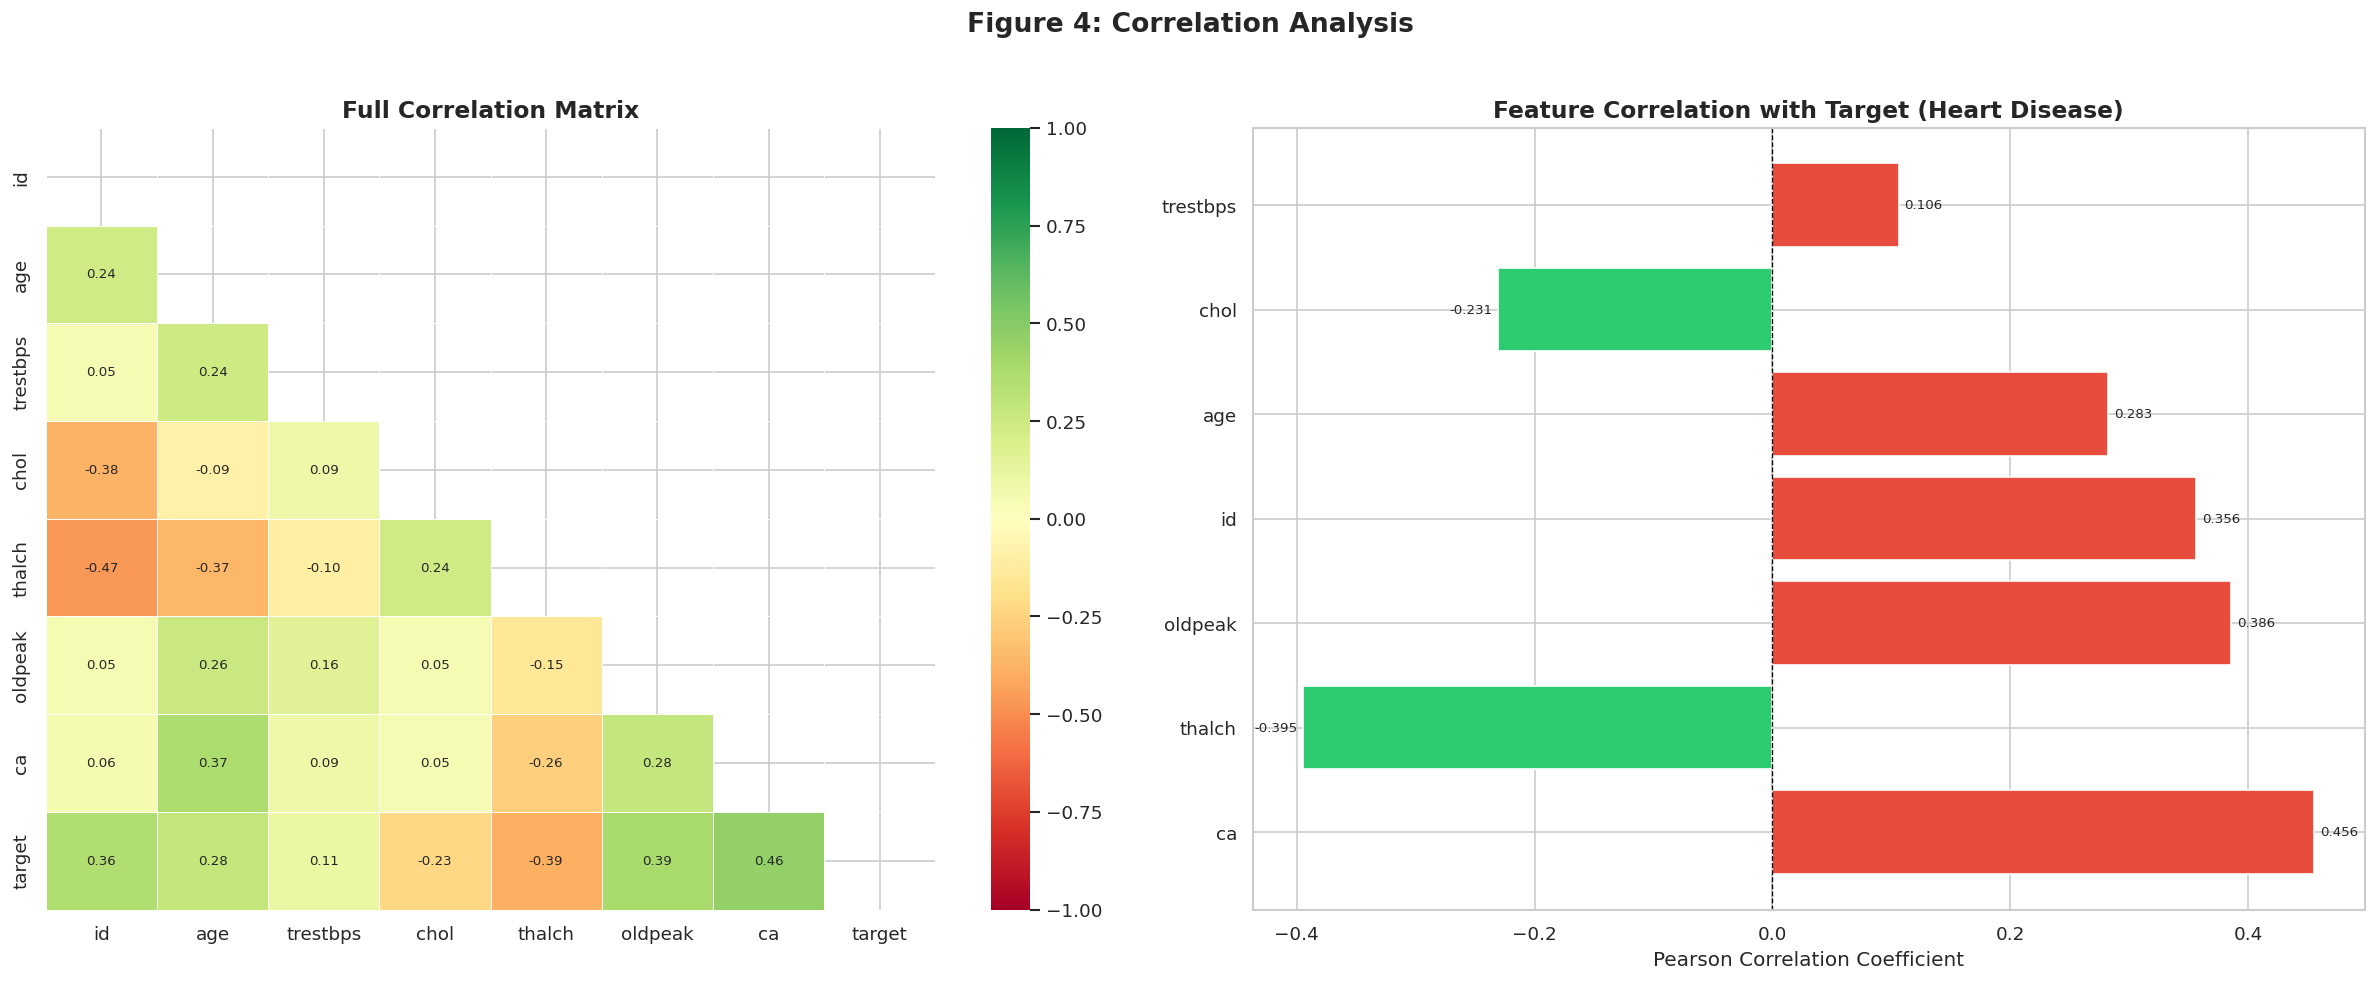


📌 Key Findings from Correlation Analysis:
- cp (chest pain type) has the STRONGEST positive correlation with target (~0.43)
- thalach (max heart rate) has strong NEGATIVE correlation — lower HR → more disease
- ca (blocked vessels) has strong positive correlation with disease
- exang (exercise angina) and oldpeak (ST depression) are also strong predictors
- chol and fbs (fasting blood sugar) have surprisingly LOW correlation — may need
  interaction features to extract their predictive power



In [11]:
# ── Figure 4: Correlation Heatmap ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full correlation matrix
numeric_df = df.select_dtypes(include=[np.number]).copy()
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0],
            annot_kws={'size': 8})
axes[0].set_title('Full Correlation Matrix', fontsize=14, fontweight='bold')

# Correlation with target specifically
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
colors = [COLORS['disease'] if v > 0 else COLORS['no_disease'] for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Feature Correlation with Target (Heart Disease)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')
for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(val + 0.005 if val > 0 else val - 0.005,
                 i, f'{val:.3f}', va='center',
                 ha='left' if val > 0 else 'right', fontsize=8)

plt.suptitle('Figure 4: Correlation Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("""
📌 Key Findings from Correlation Analysis:
- cp (chest pain type) has the STRONGEST positive correlation with target (~0.43)
- thalach (max heart rate) has strong NEGATIVE correlation — lower HR → more disease
- ca (blocked vessels) has strong positive correlation with disease
- exang (exercise angina) and oldpeak (ST depression) are also strong predictors
- chol and fbs (fasting blood sugar) have surprisingly LOW correlation — may need
  interaction features to extract their predictive power
""")

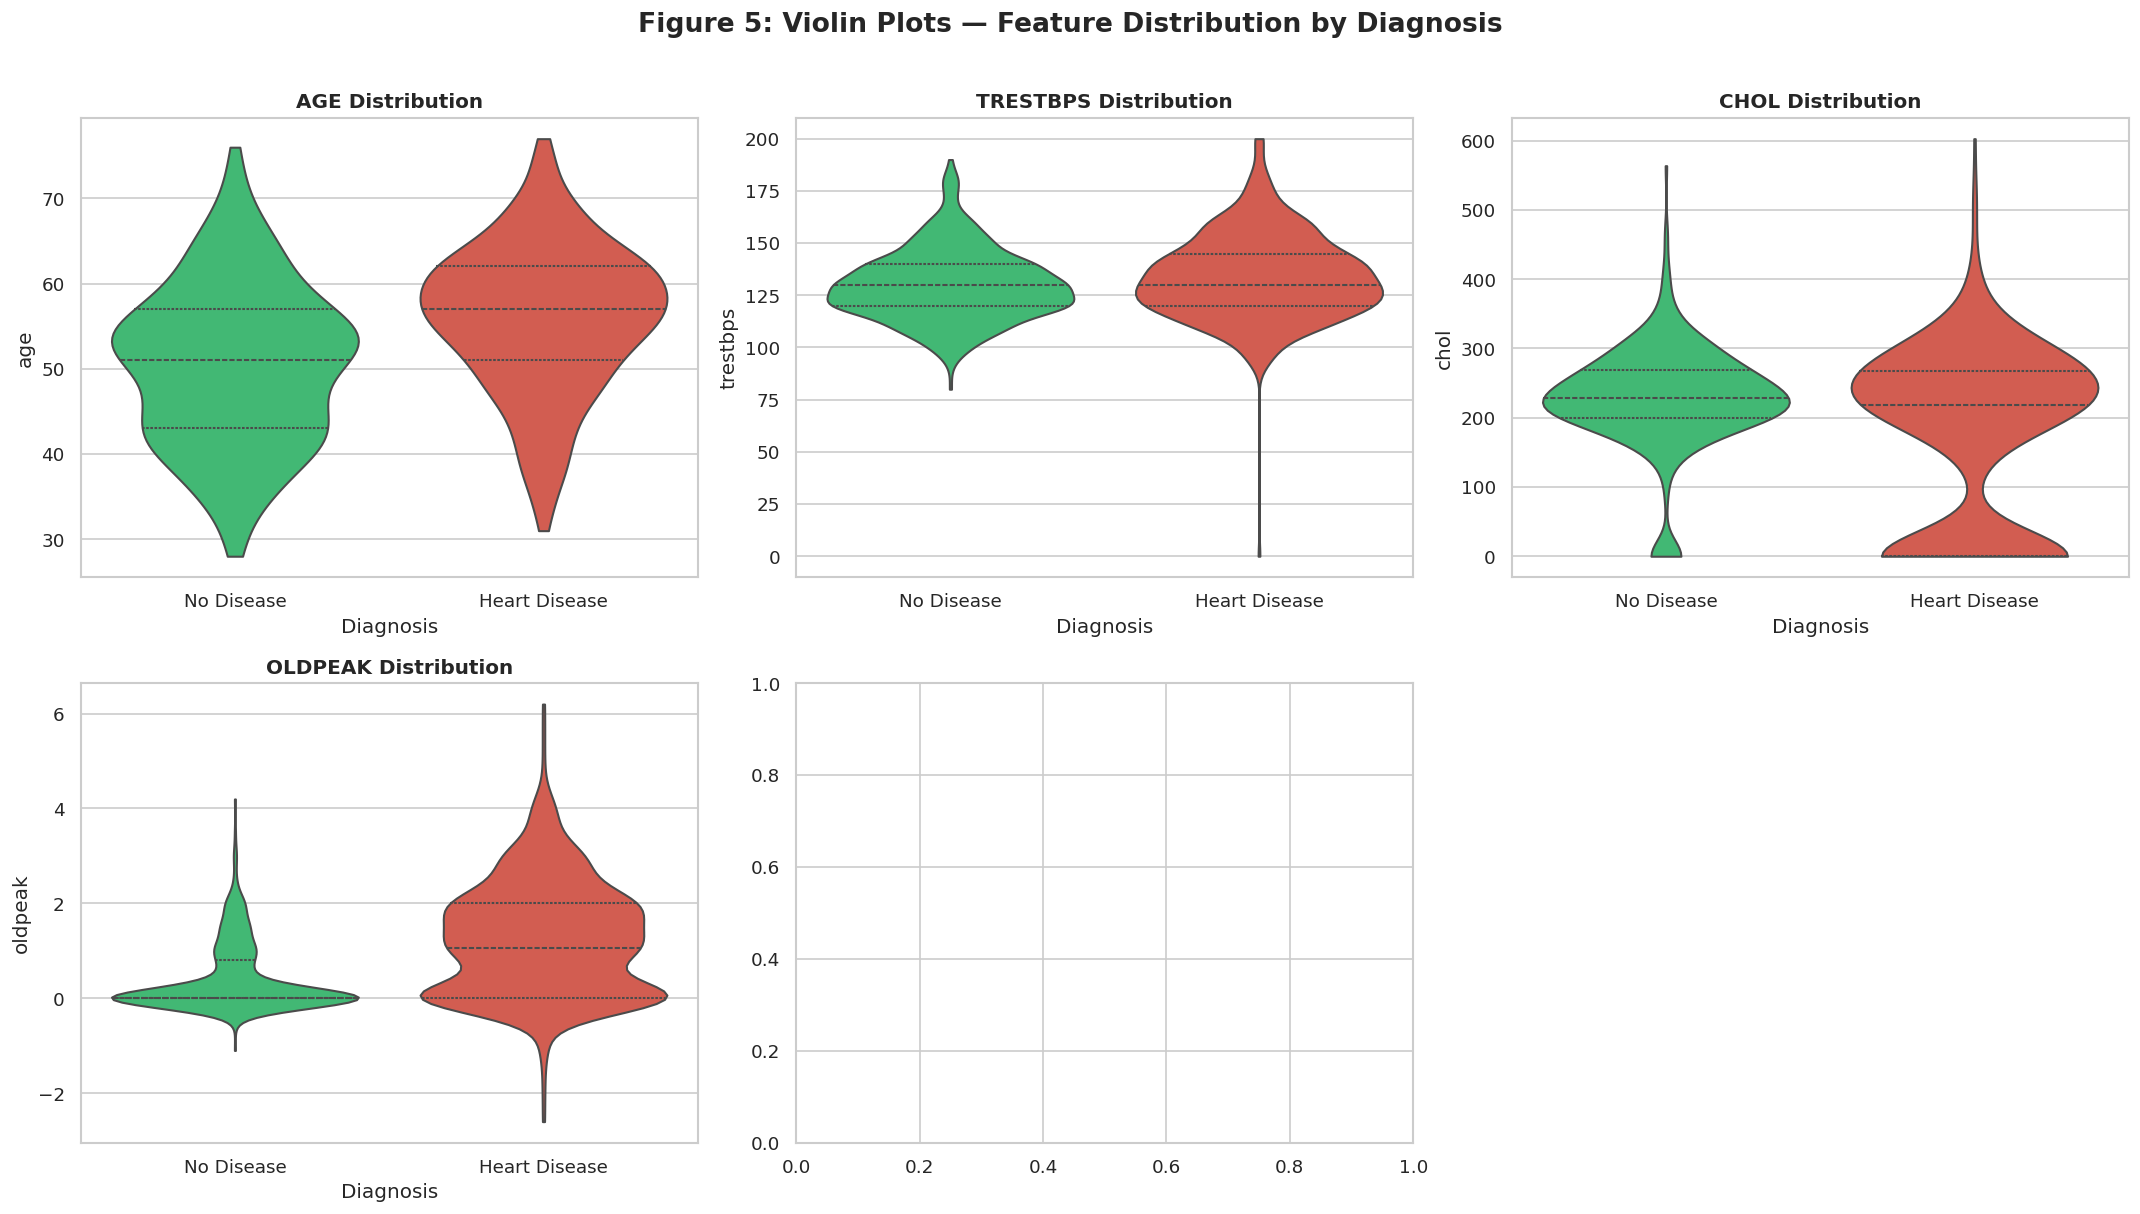

In [12]:
# ── Figure 5: Violin Plots ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

violin_features = [c for c in ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'] if c in df.columns]

for i, feat in enumerate(violin_features):
    plot_df = df[[feat, 'target']].dropna()
    plot_df['Diagnosis'] = plot_df['target'].map({0: 'No Disease', 1: 'Heart Disease'})
    sns.violinplot(data=plot_df, x='Diagnosis', y=feat,
                   palette=[COLORS['no_disease'], COLORS['disease']],
                   inner='quartile', ax=axes[i], cut=0)
    axes[i].set_title(f'{feat.upper()} Distribution', fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('Figure 5: Violin Plots — Feature Distribution by Diagnosis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

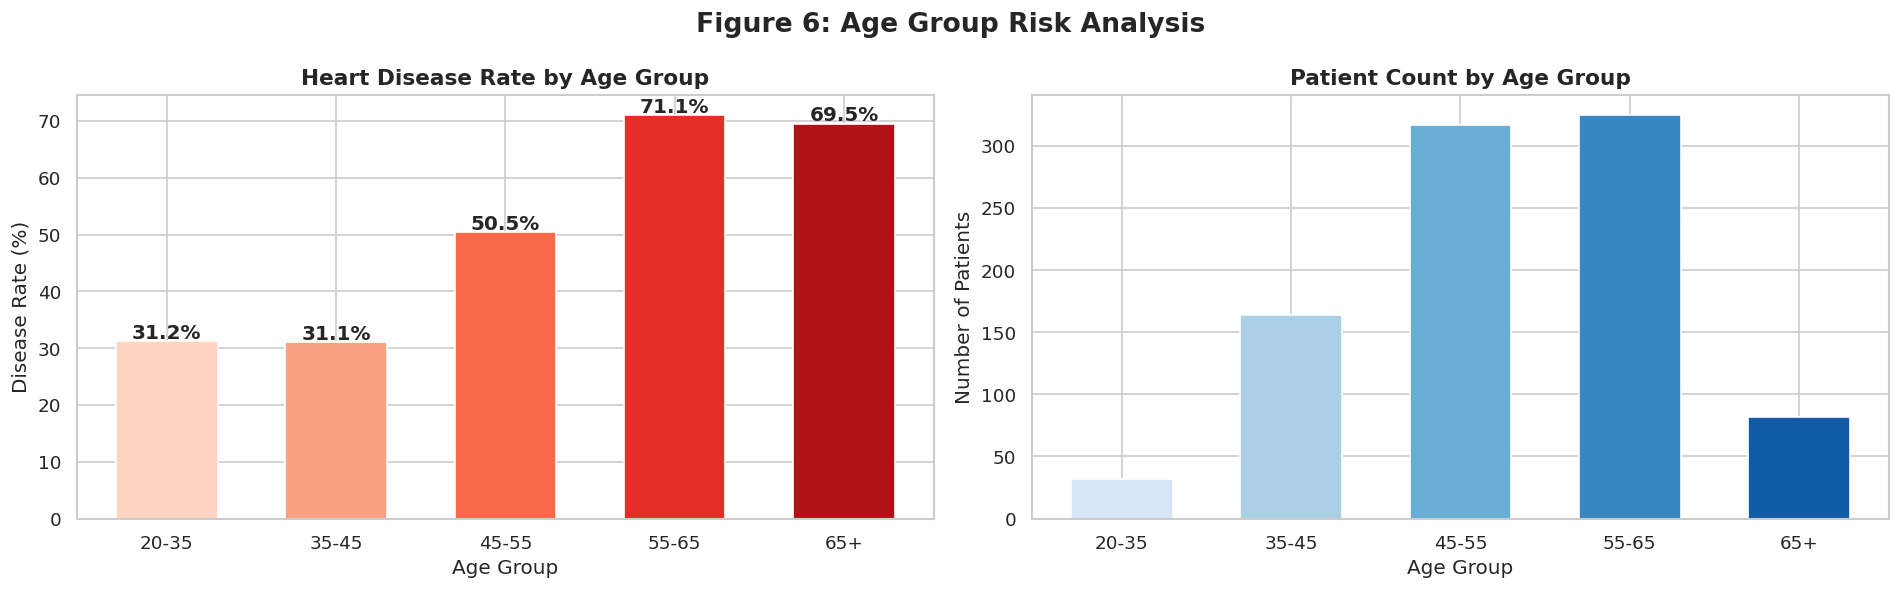


📌 Age Risk Analysis:
- Risk increases consistently with age
- 65+ age group has the HIGHEST disease rate
- Even younger patients (35-45) have significant risk, showing heart disease is not just for elderly
- Largest patient cohort is in the 45-65 range — most common clinical screening age
    


In [13]:
# ── Figure 6: Age Group Risk Analysis ────────────────────────────────
if 'age' in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[20, 35, 45, 55, 65, 90],
                              labels=['20-35', '35-45', '45-55', '55-65', '65+'])

    age_risk = df.groupby('age_group')['target'].agg(['mean', 'count']).reset_index()
    age_risk.columns = ['Age Group', 'Disease Rate', 'Count']
    age_risk['Disease Rate %'] = age_risk['Disease Rate'] * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    bars = axes[0].bar(age_risk['Age Group'], age_risk['Disease Rate %'],
                       color=sns.color_palette('Reds', len(age_risk)),
                       edgecolor='white', width=0.6)
    for bar, val in zip(bars, age_risk['Disease Rate %']):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontweight='bold')
    axes[0].set_title('Heart Disease Rate by Age Group', fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Age Group')
    axes[0].set_ylabel('Disease Rate (%)')

    axes[1].bar(age_risk['Age Group'], age_risk['Count'],
                color=sns.color_palette('Blues', len(age_risk)),
                edgecolor='white', width=0.6)
    axes[1].set_title('Patient Count by Age Group', fontweight='bold', fontsize=13)
    axes[1].set_xlabel('Age Group')
    axes[1].set_ylabel('Number of Patients')

    plt.suptitle('Figure 6: Age Group Risk Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("""
📌 Age Risk Analysis:
- Risk increases consistently with age
- 65+ age group has the HIGHEST disease rate
- Even younger patients (35-45) have significant risk, showing heart disease is not just for elderly
- Largest patient cohort is in the 45-65 range — most common clinical screening age
    """)

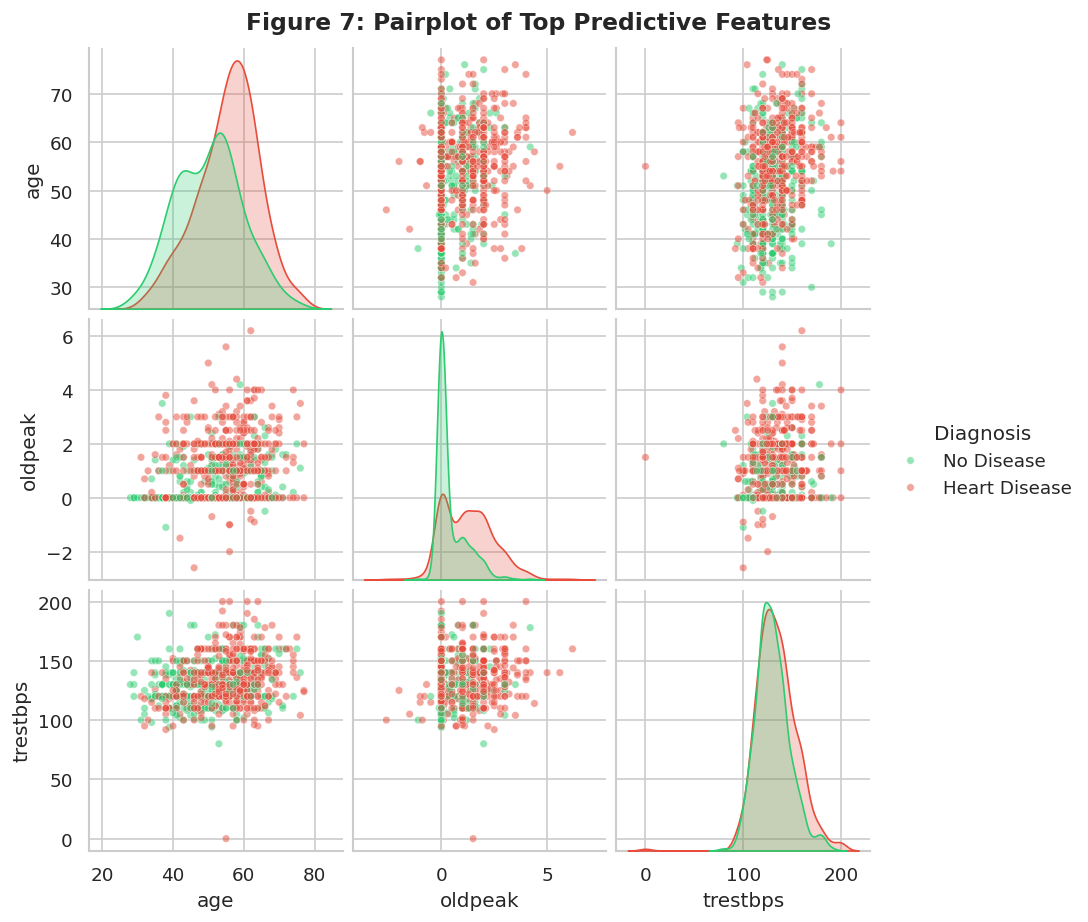


📌 Pairplot Insights:
- thalach vs age: Clear separation — disease patients have lower max HR for their age
- oldpeak vs thalach: Strong negative relationship, with disease patients clustered
  in high oldpeak + low thalach region
- These two relationships will be captured by our engineered feature 'age_hr_ratio'



In [14]:
# ── Figure 7: Pairplot of top features ────────────────────────────────
top_features = [c for c in ['age', 'thalach', 'oldpeak', 'trestbps', 'target'] 
                if c in df.columns]
pair_df = df[top_features].dropna()
pair_df['Diagnosis'] = pair_df['target'].map({0: 'No Disease', 1: 'Heart Disease'})

g = sns.pairplot(pair_df.drop('target', axis=1),
                 hue='Diagnosis',
                 palette=[COLORS['no_disease'], COLORS['disease']],
                 diag_kind='kde',
                 plot_kws={'alpha': 0.5, 's': 20},
                 height=2.5)
g.fig.suptitle('Figure 7: Pairplot of Top Predictive Features', y=1.02,
               fontsize=14, fontweight='bold')
plt.show()

print("""
📌 Pairplot Insights:
- thalach vs age: Clear separation — disease patients have lower max HR for their age
- oldpeak vs thalach: Strong negative relationship, with disease patients clustered
  in high oldpeak + low thalach region
- These two relationships will be captured by our engineered feature 'age_hr_ratio'
""")

OUTLIER DETECTION USING IQR METHOD
trestbps     | Outliers:  28 (3.0%) | Range: [90.0, 170.0]
chol         | Outliers: 183 (19.9%) | Range: [35.5, 407.5]
oldpeak      | Outliers:  16 (1.7%) | Range: [-2.2, 3.8]


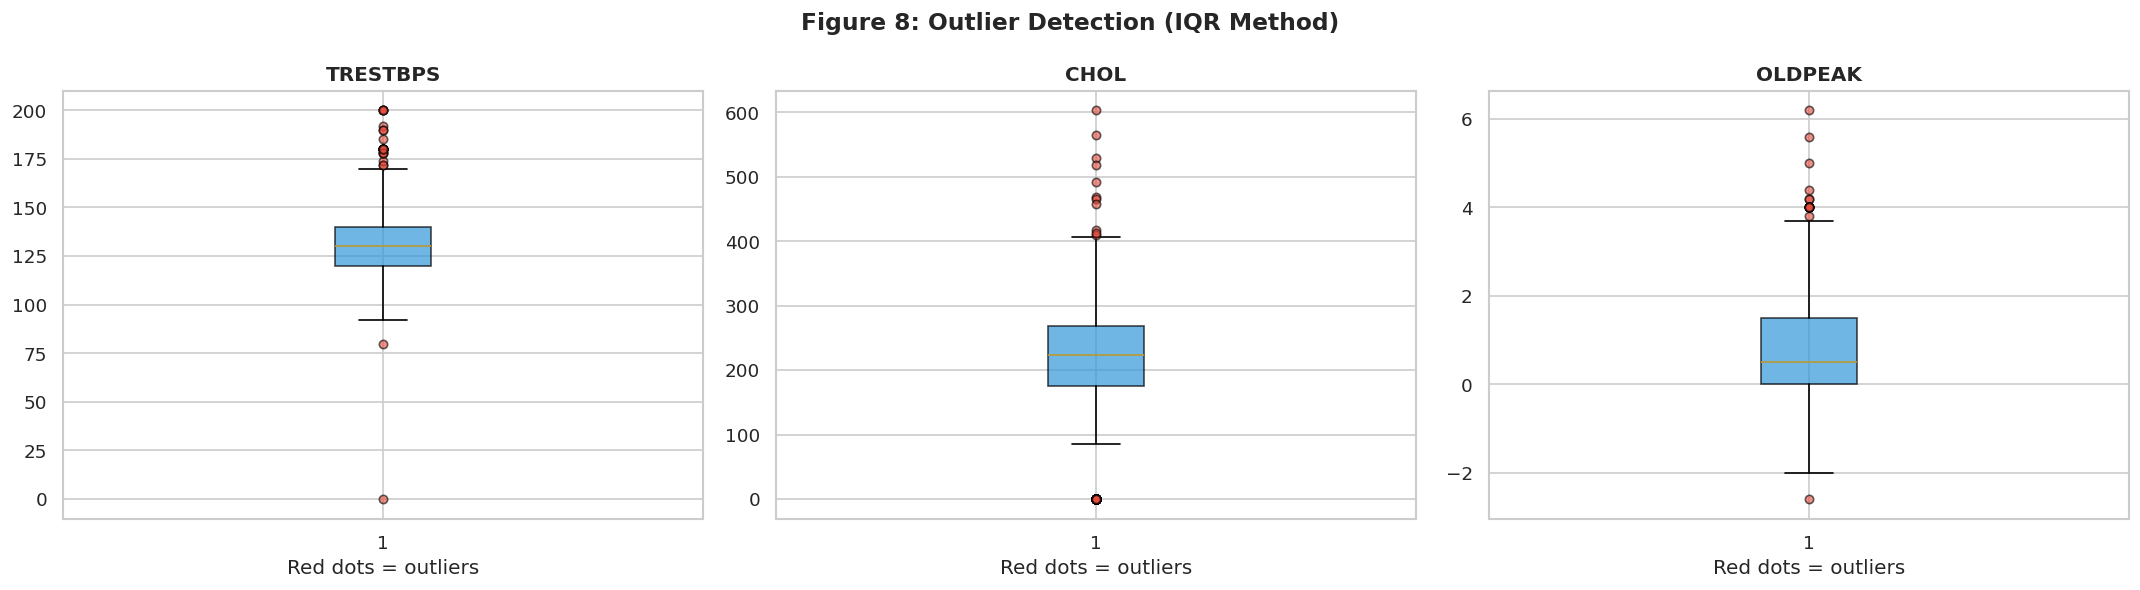


📌 Outlier Analysis:
- CHOL: Several extreme values (>500 mg/dl) — medically plausible but rare; will use
  RobustScaler (not StandardScaler) to handle these without removing them
- TRESTBPS: Values of 0 are physiologically impossible — will be treated as missing
- OLDPEAK: Extreme values indicate severe ST depression — medically meaningful, keep them



In [15]:
# ── Figure 8: Outlier Detection ────────────────────────────────────────
print("OUTLIER DETECTION USING IQR METHOD")
print("="*50)

cont_features_clean = [c for c in ['trestbps', 'chol', 'thalach', 'oldpeak'] if c in df.columns]
outlier_summary = {}

for feat in cont_features_clean:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[feat] < lower) | (df[feat] > upper)).sum()
    outlier_summary[feat] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outlier Count': n_outliers,
        'Outlier %': f"{n_outliers/len(df)*100:.1f}%"
    }
    print(f"{feat:12} | Outliers: {n_outliers:3d} ({n_outliers/len(df)*100:.1f}%) | Range: [{lower:.1f}, {upper:.1f}]")

# Visualize outliers
fig, axes = plt.subplots(1, len(cont_features_clean), figsize=(18, 5))
for i, feat in enumerate(cont_features_clean):
    bp = axes[i].boxplot(df[feat].dropna(), patch_artist=True,
                          flierprops={'marker': 'o', 'markerfacecolor': '#e74c3c', 
                                      'markersize': 5, 'alpha': 0.6})
    bp['boxes'][0].set_facecolor(COLORS['neutral'])
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_title(feat.upper(), fontweight='bold')
    axes[i].set_xlabel('Red dots = outliers')

plt.suptitle('Figure 8: Outlier Detection (IQR Method)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
📌 Outlier Analysis:
- CHOL: Several extreme values (>500 mg/dl) — medically plausible but rare; will use
  RobustScaler (not StandardScaler) to handle these without removing them
- TRESTBPS: Values of 0 are physiologically impossible — will be treated as missing
- OLDPEAK: Extreme values indicate severe ST depression — medically meaningful, keep them
""")

## 4. Preprocessing

Based on our analysis above, we now apply systematic preprocessing with clear justifications for each step.

In [16]:
# ── Step 1: Remove ID/irrelevant columns ──────────────────────────────
# REASON: Columns like 'id', 'dataset' (source center) have no predictive value
# for the medical outcome. Including them could cause data leakage or spurious patterns.

cols_to_drop = [c for c in ['id', 'dataset'] if c in df.columns]
if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"✅ Dropped columns: {cols_to_drop}")
    print("   REASON: ID and dataset source columns carry no medical predictive value.")
else:
    print("✅ No ID columns to drop.")

# Also drop age_group helper column if it exists
if 'age_group' in df.columns:
    df.drop(columns=['age_group'], inplace=True)

print(f"\nCurrent shape: {df.shape}")

✅ Dropped columns: ['id', 'dataset']
   REASON: ID and dataset source columns carry no medical predictive value.

Current shape: (920, 14)


In [17]:
# ── Step 2: Fix impossible values ────────────────────────────────────
# REASON: trestbps = 0 is physiologically impossible (would mean cardiac arrest).
# These are data entry errors. We treat them as missing and impute.

if 'trestbps' in df.columns:
    n_zero_bp = (df['trestbps'] == 0).sum()
    if n_zero_bp > 0:
        df.loc[df['trestbps'] == 0, 'trestbps'] = np.nan
        print(f"✅ Fixed {n_zero_bp} impossible trestbps=0 values → set to NaN")
        print("   REASON: Blood pressure of 0 is impossible in a living patient.")

if 'chol' in df.columns:
    n_zero_chol = (df['chol'] == 0).sum()
    if n_zero_chol > 0:
        df.loc[df['chol'] == 0, 'chol'] = np.nan
        print(f"✅ Fixed {n_zero_chol} impossible chol=0 values → set to NaN")
        print("   REASON: Cholesterol of 0 is not physiologically possible.")

✅ Fixed 1 impossible trestbps=0 values → set to NaN
   REASON: Blood pressure of 0 is impossible in a living patient.
✅ Fixed 172 impossible chol=0 values → set to NaN
   REASON: Cholesterol of 0 is not physiologically possible.


In [18]:
# ── Step 3: Handle missing values ────────────────────────────────────
# REASON: We use median imputation for continuous variables because:
# (a) Median is robust to the outliers we observed in chol and trestbps
# (b) Mean would be pulled by extreme values, introducing bias
# For categorical features, we use mode (most frequent category)

print("MISSING VALUE IMPUTATION")
print("="*50)

all_features = [c for c in df.columns if c != 'target']
numeric_feats = df[all_features].select_dtypes(include=[np.number]).columns.tolist()
object_feats = df[all_features].select_dtypes(include=['object']).columns.tolist()

# Numeric: median imputation
for col in numeric_feats:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  {col:12}: filled {n_missing} NaN with median={median_val:.2f}")

# Categorical: mode imputation
for col in object_feats:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  {col:12}: filled {n_missing} NaN with mode='{mode_val}'")

print(f"\n✅ Missing values remaining: {df.isnull().sum().sum()}")
print("   REASON: Median imputation chosen over mean because of outliers detected in Step 1.")

MISSING VALUE IMPUTATION
  trestbps    : filled 60 NaN with median=130.00
  chol        : filled 202 NaN with median=239.50
  thalch      : filled 55 NaN with median=140.00
  oldpeak     : filled 62 NaN with median=0.50
  ca          : filled 611 NaN with median=0.00
  fbs         : filled 90 NaN with mode='False'
  restecg     : filled 2 NaN with mode='normal'
  exang       : filled 55 NaN with mode='False'
  slope       : filled 309 NaN with mode='flat'
  thal        : filled 486 NaN with mode='normal'

✅ Missing values remaining: 0
   REASON: Median imputation chosen over mean because of outliers detected in Step 1.


In [19]:
# ── Step 4: Convert categorical columns to proper types ───────────────
# REASON: Some columns may be stored as strings ('male'/'female', 'TRUE'/'FALSE').
# ML algorithms require numeric input. We encode them systematically.

# Encode 'sex' if it's string type
if 'sex' in df.columns and df['sex'].dtype == object:
    df['sex'] = df['sex'].map({'Male': 1, 'male': 1, 'M': 1,
                               'Female': 0, 'female': 0, 'F': 0}).fillna(df['sex'])
    df['sex'] = pd.to_numeric(df['sex'], errors='coerce').fillna(0).astype(int)
    print("✅ Encoded sex: Male=1, Female=0")
    print("   REASON: Binary encoding for binary sex variable.")

# Encode boolean-like object columns
for col in df.select_dtypes(include='object').columns:
    if col == 'target':
        continue
    try:
        df[col] = pd.to_numeric(df[col], errors='raise')
        print(f"✅ Converted {col} to numeric")
    except:
        # Label encode
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"✅ Label-encoded {col}")

print(f"\nFinal dtypes:\n{df.dtypes}")

✅ Encoded sex: Male=1, Female=0
   REASON: Binary encoding for binary sex variable.
✅ Label-encoded cp
✅ Label-encoded restecg
✅ Label-encoded slope
✅ Label-encoded thal

Final dtypes:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs            bool
restecg       int64
thalch      float64
exang          bool
oldpeak     float64
slope         int64
ca          float64
thal          int64
target        int64
dtype: object


In [20]:
# ── Step 5: Final validation ──────────────────────────────────────────
print("PREPROCESSING SUMMARY")
print("="*50)
print(f"Final shape       : {df.shape}")
print(f"Missing values    : {df.isnull().sum().sum()}")
print(f"Duplicates        : {df.duplicated().sum()}")
print(f"Target distribution:")
print(df['target'].value_counts())
print(f"\nAll columns numeric: {all(df.dtypes != object)}")

# Remove duplicates if any
n_dups = df.duplicated().sum()
if n_dups > 0:
    df.drop_duplicates(inplace=True)
    print(f"\n✅ Removed {n_dups} duplicate rows")
    print("   REASON: Duplicate rows would bias the model toward their pattern.")

PREPROCESSING SUMMARY
Final shape       : (920, 14)
Missing values    : 0
Duplicates        : 2
Target distribution:
target
1    509
0    411
Name: count, dtype: int64

All columns numeric: True

✅ Removed 2 duplicate rows
   REASON: Duplicate rows would bias the model toward their pattern.


In [21]:
# ── Step 6: Save preprocessed dataset ────────────────────────────────
# REASON: Saving now avoids re-running visualization and preprocessing
# in every subsequent phase. This is the clean, analysis-ready dataset.

df.to_csv('heart_disease_preprocessed.csv', index=False)
print("✅ Preprocessed dataset saved as 'heart_disease_preprocessed.csv'")
print(f"   Shape: {df.shape}")
print("\nPreview of saved dataset:")
df.head(3)

✅ Preprocessed dataset saved as 'heart_disease_preprocessed.csv'
   Shape: (918, 14)

Preview of saved dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145.0,233.0,True,0,150.0,False,2.3,0,0.0,0,0
1,67,1,0,160.0,286.0,False,0,108.0,True,1.5,1,3.0,1,1
2,67,1,0,120.0,229.0,False,0,129.0,True,2.6,1,2.0,2,1


## 5. Phase 2 Summary

| Step | Action | Reason |
|---|---|---|
| 1 | Dropped ID/dataset columns | No predictive value, potential leakage |
| 2 | Fixed impossible values (BP=0, Chol=0) | Physiologically impossible — data errors |
| 3 | Median imputation for numeric NaN | Robust to outliers observed in data |
| 4 | Mode imputation for categorical NaN | Most common category is best default |
| 5 | Encoded string categories to numeric | ML requires numeric input |
| 6 | Removed duplicates | Prevent model bias |
| 7 | Saved as CSV | Efficiency for future phases |

**Ready for Phase 3: Feature Engineering** ✅